In [48]:
print("Hello")

Hello


In [49]:
!ls

00sequences.txt  boxing  handclapping  handwaving  jogging  running  walking


In [50]:
!kaggle datasets download -d vafaeii/kth-action-recognition-dataset

Dataset URL: https://www.kaggle.com/datasets/vafaeii/kth-action-recognition-dataset
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 1.07G/1.07G [00:16<00:00, 71.4MB/s]



In [51]:
!unzip -q kth-action-recognition-dataset.zip -d ./kth_dataset && rm kth-action-recognition-dataset.zip

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [53]:
PATH = "kth_dataset"

final_path = os.path.join(os.getcwd())

os.chdir(final_path)

print(os.listdir())

['00sequences.txt', 'boxing', 'running', 'walking', 'handclapping', 'handwaving', 'jogging', 'kth_dataset']


In [54]:
os.chdir("kth_dataset")

In [55]:
print(os.listdir())

['00sequences.txt', 'boxing', 'running', 'walking', 'handclapping', 'handwaving', 'jogging']


In [56]:
from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [57]:
!ls

00sequences.txt  boxing  handclapping  handwaving  jogging  running  walking


In [58]:
DATASET_PATH = "."

len of frames are 378
shape of single frame is (120, 160)


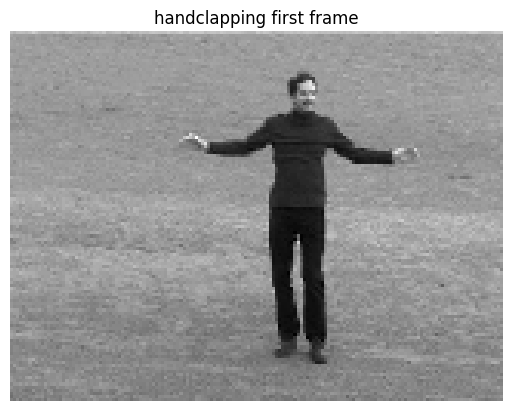

In [59]:
import cv2
import matplotlib.pyplot as plt

# VIDEO_PATH = "boxing/person01_boxing_d1_uncomp.avi"
ACTION = "handclapping"

VIDEO_PATH = f"{ACTION}/person01_handclapping_d1_uncomp.avi"

capture = cv2.VideoCapture(VIDEO_PATH)

frames = []

while True:
  success,frame = capture.read()
  if not success:
    break

  frame = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
  frames.append(frame)

capture.release()

print(f"len of frames are {len(frames)}")

print(f"shape of single frame is {frames[0].shape}")

plt.imshow(frames[0],cmap="gray")
plt.title(f"{ACTION} first frame")
plt.axis("off")
plt.show()

In [60]:
frames[0].shape

(120, 160)

### Implement HOG

In [61]:
def compute_gradients(image):
  image = image.astype(float)

  gx = np.zeros(image.shape)
  gy = np.zeros(image.shape)

  #gx = I(x+1,y) -I(x-1,y)
  gx[:,1:-1] = (image[:,2:]-image[:,:-2]) / 2

  #gy = I(x,y+1) - I(x,y-1)
  gy[1:-1,:] = (image[2:,:]-image[:-2,:]) / 2

  g = np.sqrt(gx**2 + gy**2)
  orientation = np.rad2deg(np.arctan2(gy,gx))

  orientation[orientation < 0] += 180

  return g,orientation

In [62]:
magnitude,orientation = compute_gradients(frames[0])

print(magnitude.shape,orientation.shape)

print(f"min magnitude is {magnitude.min()} and max magnitude is {magnitude.max()}")
print(f"min orientation is {orientation.min()} and max orientation is {orientation.max()}")

(120, 160) (120, 160)
min magnitude is 0.0 and max magnitude is 101.11874208078342
min orientation is 0.0 and max orientation is 180.0


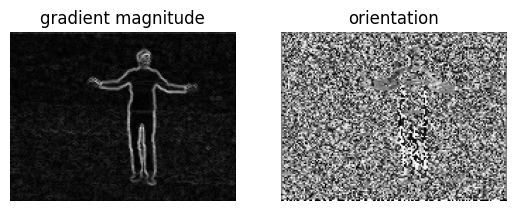

In [63]:
fig,axes = plt.subplots(1,2)

axes[0].imshow(magnitude,cmap="gray")
axes[0].set_title("gradient magnitude")
axes[0].axis("off")

axes[1].imshow(orientation,cmap="gray")
axes[1].set_title("orientation")
axes[1].axis("off")

plt.show()

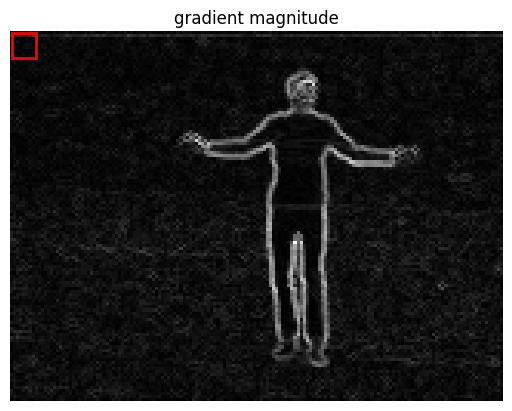

In [64]:
from matplotlib.patches import Rectangle

plt.imshow(magnitude, cmap="gray")
rect = Rectangle((0, 0),8,8,fill=False,edgecolor="red",linewidth=2)
plt.gca().add_patch(rect)
plt.title("gradient magnitude")
plt.axis("off")
plt.show()

In [65]:
def create_cell_histogram(magnitude,orientation,cell_size=8,bins=9):
    h,w=magnitude.shape

    cells_x=w//cell_size
    cells_y=h//cell_size

    hist=np.zeros((cells_y,cells_x,bins))

    bin_width=180/bins

    for i in range(cells_y):
        for j in range(cells_x):
            mag_cell=magnitude[
                i*cell_size:(i+1)*cell_size,
                j*cell_size:(j+1)*cell_size
            ]

            ori_cell=orientation[
                i*cell_size:(i+1)*cell_size,
                j*cell_size:(j+1)*cell_size
            ]


            for x in range(cell_size):
                for y in range(cell_size):
                    angle=ori_cell[x,y]

                    b=int(angle//bin_width)

                    if b==bins:
                        b=0
                    hist[i,j,b]+=mag_cell[x,y]
    return hist

In [66]:
cell_histogram = create_cell_histogram(magnitude,orientation)

In [67]:
print(cell_histogram.shape)

(15, 20, 9)


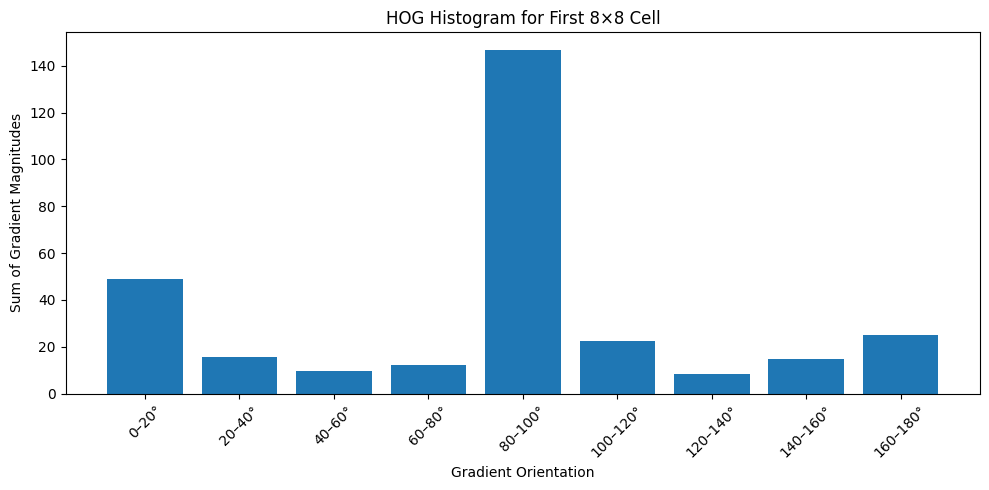

In [68]:
cell_mag = magnitude[0:8, 0:8]
cell_ori = orientation[0:8, 0:8]

bins = 9
bin_width = 180 / bins

hist = np.zeros(bins)

for i in range(8):
    for j in range(8):

        angle = cell_ori[i, j]
        mag = cell_mag[i, j]

        b = int(angle // bin_width)

        if b == bins:
            b = 0

        hist[b] += mag

bin_labels = [
    "0–20°",
    "20–40°",
    "40–60°",
    "60–80°",
    "80–100°",
    "100–120°",
    "120–140°",
    "140–160°",
    "160–180°"
]

plt.figure(figsize=(10, 5))
plt.bar(bin_labels, hist)
plt.xlabel("Gradient Orientation")
plt.ylabel("Sum of Gradient Magnitudes")
plt.title("HOG Histogram for First 8×8 Cell")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
print(np.round(cell_histogram[0, 0], 3))

[ 48.845  15.793   9.736  12.359 146.934  22.461   8.529  14.625  25.102]


In [70]:
def normalize_blocks(hist):
  eps = 1e-5

  h,w,bins=hist.shape

  features = []

  for i in range(h-1):
    for j in range(w-1):
      block = hist[i:i+2,j:j+2,:]
      vector = block.flatten()

      norm = np.sqrt(np.sum(vector**2) + eps)

      vector = vector/norm
      features.extend(vector)

  return np.array(features)

In [71]:
hog_feature=normalize_blocks(cell_histogram)

print("Hog Feature Length:",hog_feature.shape)

Hog Feature Length: (9576,)


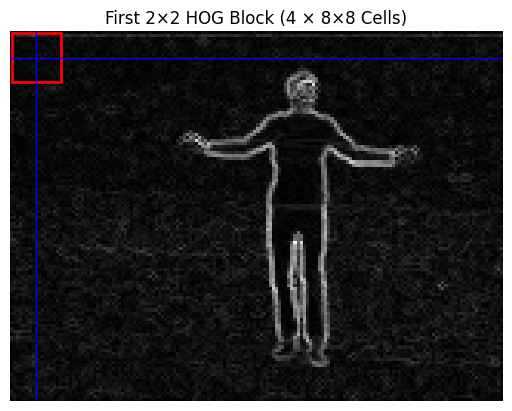

In [72]:
from matplotlib.patches import Rectangle

plt.imshow(magnitude, cmap="gray")

# First 2×2 HOG block = 16×16 pixels
rect = Rectangle(
    (0, 0),
    16,
    16,
    fill=False,
    edgecolor="red",
    linewidth=2
)

plt.gca().add_patch(rect)

# Draw the 8×8 cell boundaries
plt.axvline(8, color="blue", linewidth=1)
plt.axhline(8, color="blue", linewidth=1)

plt.title("First 2×2 HOG Block (4 × 8×8 Cells)")
plt.axis("off")

plt.show()

In [73]:
def extract_video_hog(frames):
  features = []

  for idx,frame in enumerate(frames):
    magnitude,orientation = compute_gradients(frame)
    hist = create_cell_histogram(magnitude,orientation)
    feature = normalize_blocks(hist)

    features.append(feature)

    if idx % 50 == 0:
      print("Processed Frame:",idx)

  features = np.array(features)
  print(f"frame feature matrix : {features.shape}")

  video_feature = np.mean(features,axis=0)
  print(f"video feature {video_feature.shape}")

  return video_feature

## Now Optical Flow From Scratch


In [74]:
def compute_optical_flow_gradients(frame1,frame2):
  frame1 = frame1.astype(float)
  frame2 = frame2.astype(float)

  Ix = np.zeros_like(frame1)
  Iy = np.zeros_like(frame1)

  Ix[:,1:-1] = (frame1[:,2:]-frame1[:,:-2]) / 2
  Iy[1:-1,:] = (frame1[2:,:]-frame1[:-2,:]) / 2

  It = frame2-frame1

  return Ix,Iy,It

In [75]:
frame1,frame2 = frames[0],frames[20]
Ix,Iy,It = compute_optical_flow_gradients(frame1,frame2)
print(Ix.shape,Iy.shape,It.shape)

(120, 160) (120, 160) (120, 160)


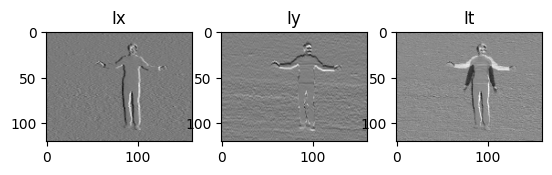

In [76]:
fig,axes = plt.subplots(1,3)

axes[0].set_title("Ix")
axes[0].imshow(Ix,cmap="gray")

axes[1].set_title("Iy")
axes[1].imshow(Iy,cmap="gray")

axes[2].set_title("It")
axes[2].imshow(It,cmap="gray")

In [77]:
def lucas_kanade(Ix, Iy, It, windows_size=5):
    h, w = Ix.shape

    u = np.zeros_like(Ix)
    v = np.zeros_like(Ix)

    offset = windows_size // 2

    for y in range(offset, h-offset):
        for x in range(offset, w-offset):

            Ix_window = Ix[
                y-offset:y+offset+1,
                x-offset:x+offset+1
            ].flatten()

            Iy_window = Iy[
                y-offset:y+offset+1,
                x-offset:x+offset+1
            ].flatten()

            It_window = It[
                y-offset:y+offset+1,
                x-offset:x+offset+1
            ].flatten()

            A = np.vstack((Ix_window, Iy_window)).T
            B = -It_window

            try:
                velocity = np.linalg.inv(A.T @ A) @ A.T @ B

                u[y, x] = velocity[0]
                v[y, x] = velocity[1]

            except:
                pass

    return u, v

In [78]:
u,v=lucas_kanade(Ix,Iy,It)

print(u.shape,v.shape)

(120, 160) (120, 160)


<Figure size 1000x400 with 0 Axes>

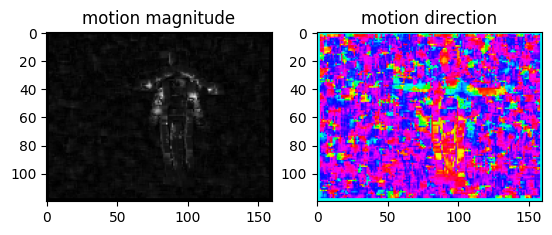

In [79]:
flow_magnitude = np.sqrt(u**2 + v**2)
flow_angle=np.arctan2(v,u)

plt.figure(figsize=(10,4))
figure,axes = plt.subplots(1,2)

axes[0].imshow(flow_magnitude,cmap="gray")
axes[0].set_title("motion magnitude")

axes[1].imshow(flow_angle,cmap="hsv")
axes[1].set_title("motion direction")

plt.show()

In [80]:
def flow_feature(u,v):
    feature=np.concatenate([u.flatten(),v.flatten()])
    return feature

In [81]:
flow_vec=flow_feature(u,v)

print("optical flow vector:",flow_vec.shape)

optical flow vector: (38400,)


In [82]:
def extract_video_flow(frames):
    features=[]

    for i in range(len(frames)-1):
        Ix,Iy,It = compute_optical_flow_gradients(frames[i],frames[i+1])

        u,v = lucas_kanade(Ix,Iy,It)
        feat = flow_feature(u,v)

        features.append(feat)

        if i%50==0:
            print(f"processed pair : {i}")

    features=np.array(features)
    print("flow matrix: ",features.shape)
    video_flow=np.mean(features,axis=0)
    print(f"video flow feature:{video_flow.shape}")

    return video_flow

In [83]:
flow_vec = flow_feature(u,v)

print(type(flow_vec))
print(flow_vec.shape)

<class 'numpy.ndarray'>
(38400,)


In [84]:
#concatenate so that feature = [HOG,Flow]
final_feature = np.concatenate(
    [
        hog_feature,
        flow_vec
    ]
)

print(final_feature.shape)

(47976,)


In [85]:
classes = ["boxing","handclapping","handwaving","jogging","running","walking"]

label_map = {
    "boxing":0,
    "handclapping":1,
    "handwaving":2,
    "jogging":3,
    "running":4,
    "walking":5
}


print(label_map)

{'boxing': 0, 'handclapping': 1, 'handwaving': 2, 'jogging': 3, 'running': 4, 'walking': 5}


In [86]:
def read_video(path):
    cap=cv2.VideoCapture(path)

    frames=[]
    while True:
        success,frame=cap.read()

        if not success:
            break

        frame=cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
        frames.append(frame)

    cap.release()
    return frames

In [87]:
video_path="boxing/person01_boxing_d1_uncomp.avi"

frames=read_video(video_path)

print(f"Number of frames: {len(frames)}")
print(f"Frame shape:{frames[0].shape}")

Number of frames: 360
Frame shape:(120, 160)


In [88]:
#Video Feature Extractor

def extract_video_descriptor(frames):
  print("Extracting hog.....")

  hog_vector = extract_video_hog(frames)

  print("Extracting optical flow...")
  flow_vector = extract_video_flow(frames)

  print("now, just combiting bots")
  video_descriptor = np.concatenate([hog_vector,flow_vector])

  print(f"shape of final descriptor is {video_descriptor.shape}")
  return video_descriptor

In [89]:
descriptor = extract_video_descriptor(frames)

Extracting hog.....
Processed Frame: 0
Processed Frame: 50
Processed Frame: 100
Processed Frame: 150
Processed Frame: 200
Processed Frame: 250
Processed Frame: 300
Processed Frame: 350
frame feature matrix : (360, 9576)
video feature (9576,)
Extracting optical flow...
processed pair : 0
processed pair : 50
processed pair : 100
processed pair : 150
processed pair : 200
processed pair : 250
processed pair : 300
processed pair : 350
flow matrix:  (359, 38400)
video flow feature:(38400,)
now, just combiting bots
shape of final descriptor is (47976,)


In [90]:
#Extract features from all videos

In [ ]:
import glob

DATASET_PATH="."
X=[]
y=[]

for action in classes:
    folder=os.path.join(DATASET_PATH,action)
    videos=glob.glob(folder+"/*.avi")

    print("\nAction:",action)
    print("Videos:",len(videos))

    for video in videos:
        print("\nProcessing:",video)
        frames = read_video(video)

        descriptor=extract_video_descriptor(frames)
        X.append(descriptor)

        y.append(label_map[action])


Action: boxing
Videos: 100

Processing: ./boxing/person19_boxing_d4_uncomp.avi
Extracting hog.....
Processed Frame: 0
Processed Frame: 50
Processed Frame: 100
Processed Frame: 150
Processed Frame: 200
Processed Frame: 250
Processed Frame: 300
Processed Frame: 350
Processed Frame: 400
frame feature matrix : (420, 9576)
video feature (9576,)
Extracting optical flow...
processed pair : 0
processed pair : 50
processed pair : 100
processed pair : 150
processed pair : 200
processed pair : 250
processed pair : 300
processed pair : 350
processed pair : 400
flow matrix:  (419, 38400)
video flow feature:(38400,)
now, just combiting bots
shape of final descriptor is (47976,)

Processing: ./boxing/person23_boxing_d2_uncomp.avi
Extracting hog.....
Processed Frame: 0
Processed Frame: 50
Processed Frame: 100
Processed Frame: 150
Processed Frame: 200
Processed Frame: 250
Processed Frame: 300
Processed Frame: 350
Processed Frame: 400
Processed Frame: 450
frame feature matrix : (500, 9576)
video featur

In [ ]:
X = np.array(X)
y = np.array(y)
print(f"feature matrix is:{X.shape} and label shape is {y.shape}")

np.save(np.save("KTH_features.npy",X))
np.save("KTH_labels.npy",y)

In [ ]:
unique,count=np.unique(y,return_counts=True)

for u,c in zip(unique,count):
    print(classes[u],c)

## Implementing SVM

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y)

print("Training:",X_train.shape)
print("Testing:",X_test.shape)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
from sklearn.svm import SVC

svm=SVC(kernel="rbf",C=10,gamma="scale")
svm.fit(X_train,y_train)

In [ ]:
y_pred=svm.predict(X_test)

print(y_pred[:20])

In [ ]:
from sklearn.metrics import accuracy_score

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)

print(cm)

In [ ]:
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(cm,annot=True,fmt="d",xticklabels=classes,yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred,target_names=classes))


In [ ]:
import pickle

with open("hog_flow_svm.pkl","wb") as f:
    pickle.dump(svm,f)

with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)


In [ ]:
print("done")